# 项目：可视化帕默群岛企鹅数据

## 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

## 简介

原始数据`Penguins.csv`包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- species：企鹅的种类
- island：企鹅所在岛
- culmen_length_mm：企鹅嘴峰的长度（单位为毫米）
- culmen_depth_mm：企鹅嘴峰的深度（单位为毫米）
- flipper_length_mm：企鹅鳍的长度（单位为毫米）
- body_mass_g：企鹅体重（单位为克）
- sex：企鹅性别

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
penguins_original = pd.read_csv("penguins.csv")
penguins_original

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [3]:
# 接下来进行初步的数据清理
penguins_cleaned = penguins_original.dropna()
penguins_cleaned

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [4]:
penguins_cleaned['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

In [5]:
penguins_cleaned['island'].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

In [6]:
penguins_cleaned['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [7]:
penguins_cleaned.drop(penguins_cleaned[penguins_cleaned['sex'] == '.'].index,inplace = True)

C:\Users\username\AppData\Local\Temp\ipykernel_10436\2425821695.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned.drop(penguins_cleaned[penguins_cleaned['sex'] == '.'].index,inplace = True)


In [8]:
penguins_cleaned['species'] = penguins_cleaned['species'].astype('category')
penguins_cleaned['island'] = penguins_cleaned['island'].astype('category')
penguins_cleaned['sex'] = penguins_cleaned['sex'].astype('category')

C:\Users\username\AppData\Local\Temp\ipykernel_10436\4091129236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned['species'] = penguins_cleaned['species'].astype('category')
C:\Users\username\AppData\Local\Temp\ipykernel_10436\4091129236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_cleaned['island'] = penguins_cleaned['island'].astype('category')
C:\Users\username\AppData\Local\Temp\ipykernel_10436\4091129236.py:3: SettingWithCopyWarning: 
A value is trying to be set on a 

In [9]:
# 进行自由分析和处理

In [10]:
sns.set_palette('pastel')

In [11]:
penguins_cleaned

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


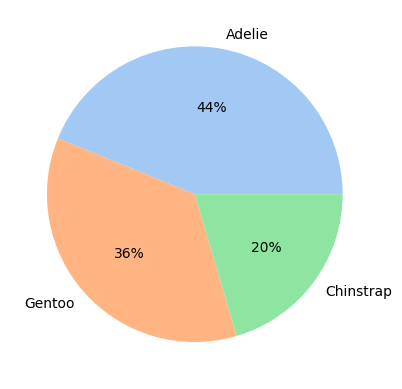

In [12]:
species_counts = penguins_cleaned['species'].value_counts()
plt.pie(species_counts,labels=species_counts.index,autopct = '%.0f%%')
plt.show()

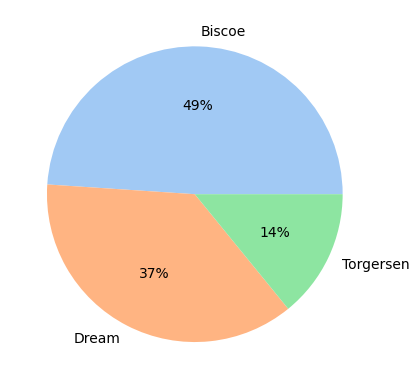

In [13]:
island_counts = penguins_cleaned['island'].value_counts()
plt.pie(island_counts,labels=island_counts.index,autopct = '%.0f%%')
plt.show()

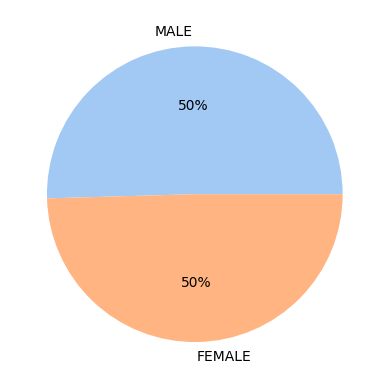

In [14]:
sex_counts = penguins_cleaned['sex'].value_counts()
plt.pie(sex_counts,labels=sex_counts.index,autopct = '%.0f%%')
plt.show()

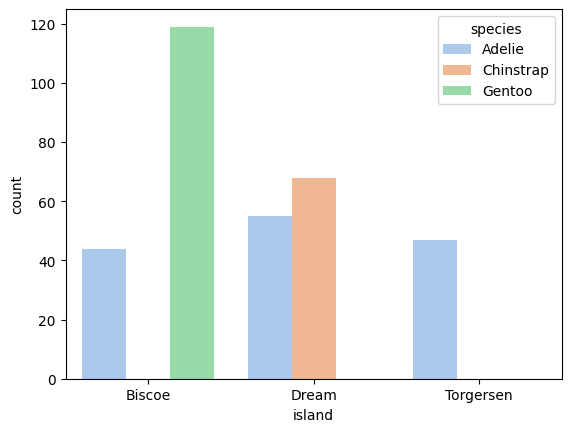

In [15]:
sns.countplot(penguins_cleaned, x='island', hue='species')
plt.show()

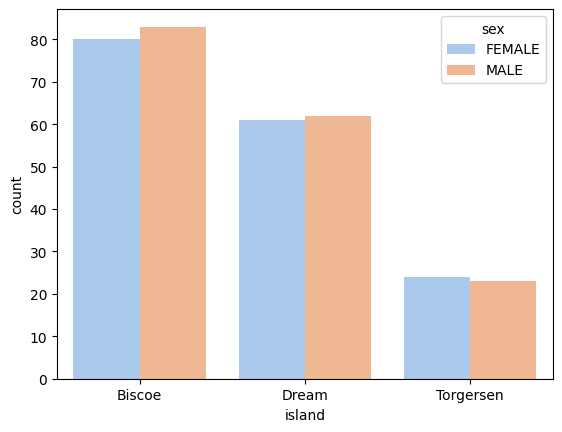

In [16]:
sns.countplot(penguins_cleaned, x='island', hue='sex')
plt.show()

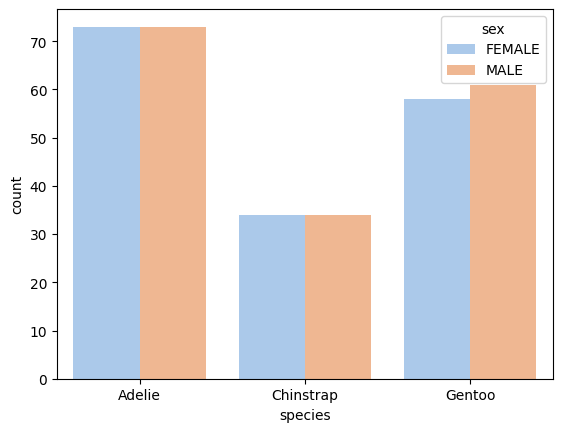

In [17]:
sns.countplot(penguins_cleaned, x='species', hue='sex')
plt.show()

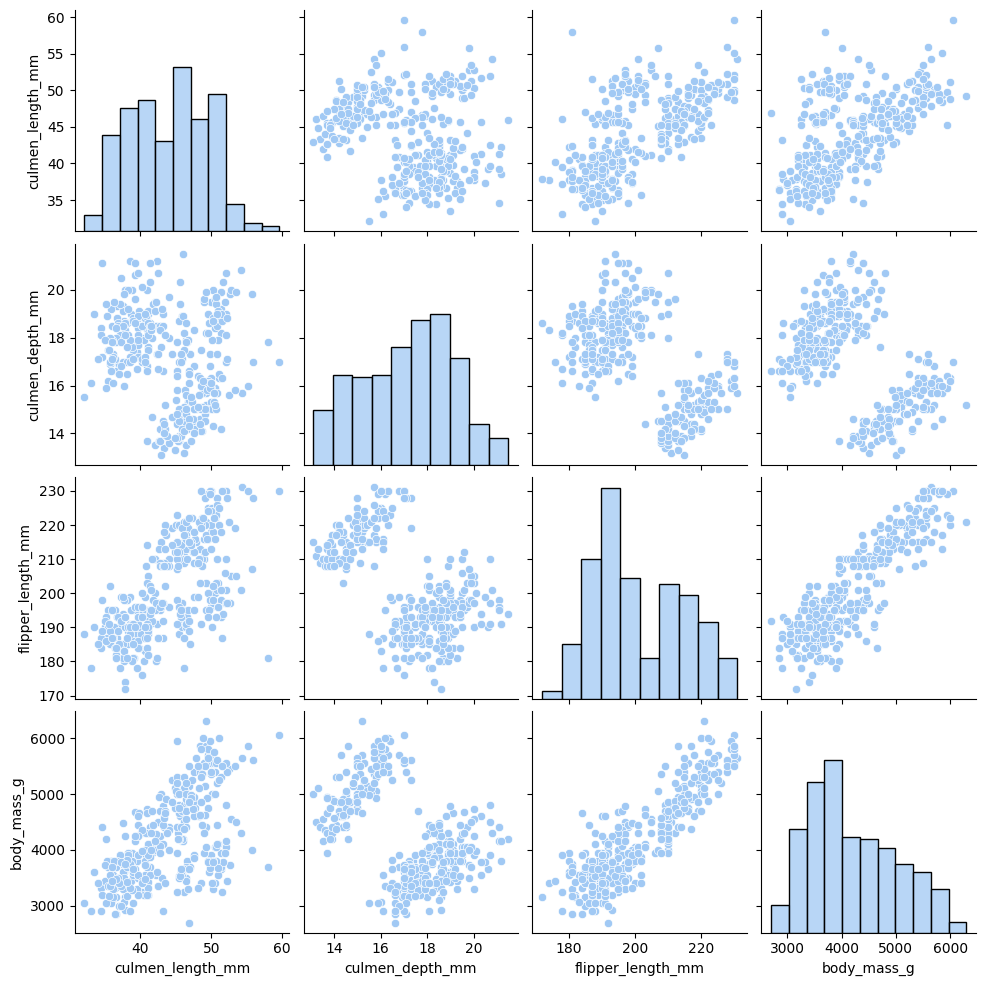

In [19]:
sns.pairplot(penguins_cleaned)
plt.show()

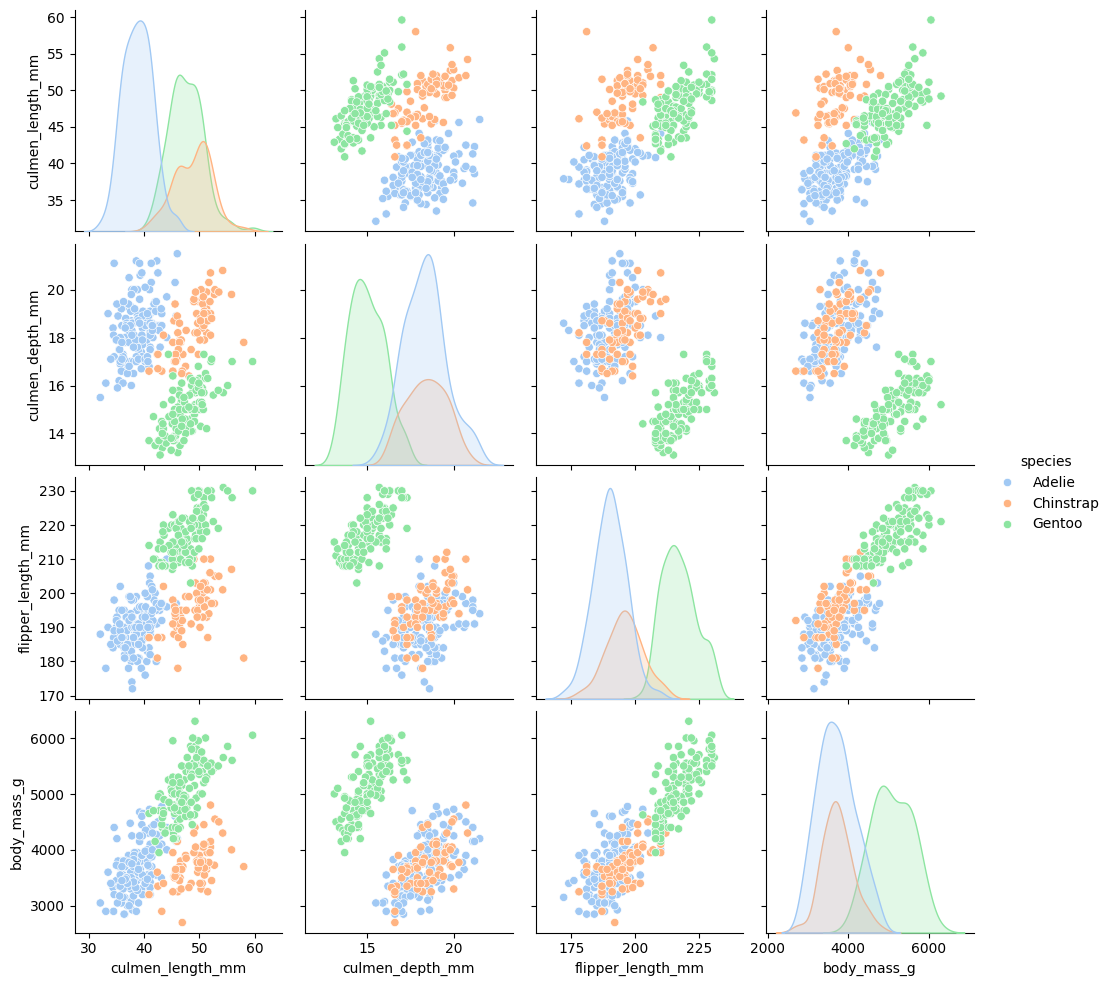

In [20]:
sns.pairplot(penguins_cleaned, hue="species")
plt.show()

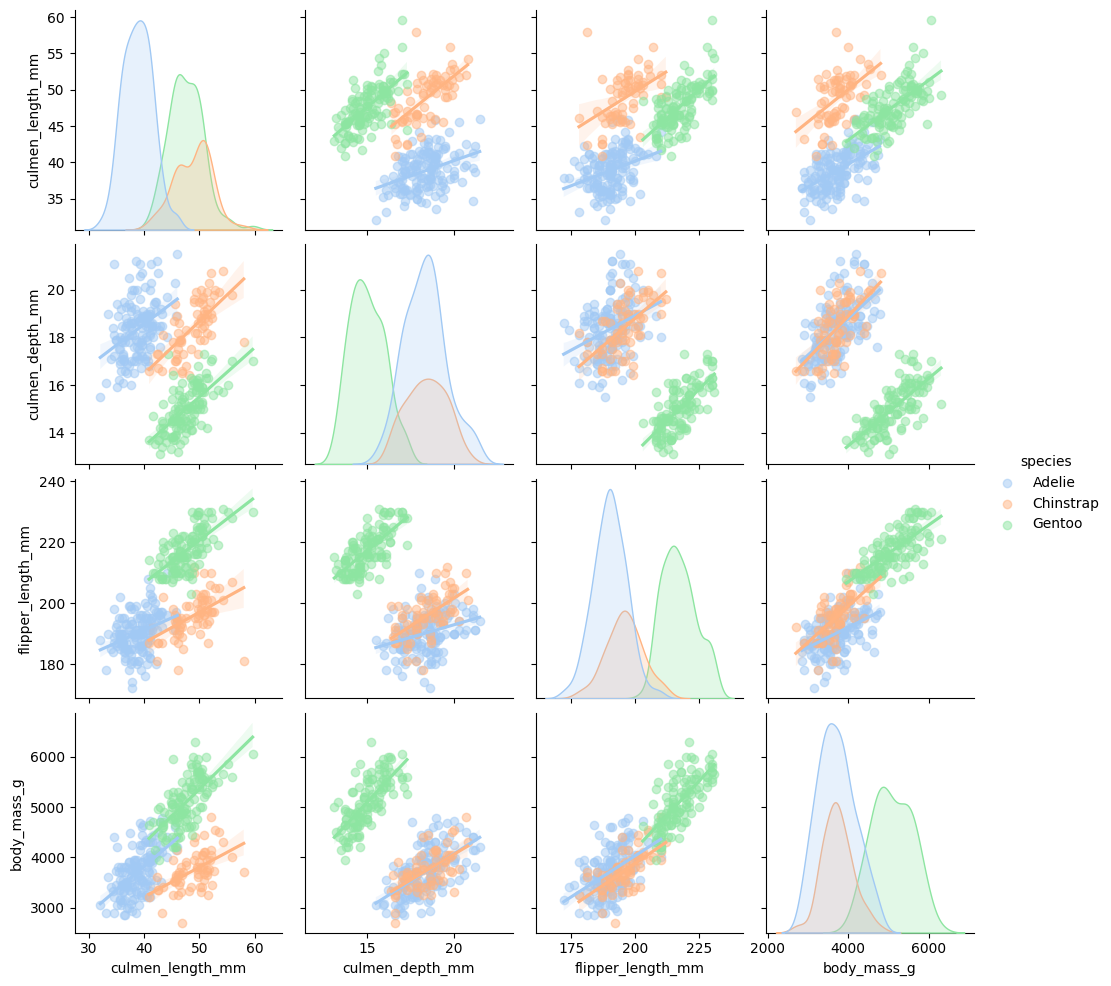

In [22]:
sns.pairplot(penguins_cleaned, hue="species", kind='reg', plot_kws={'scatter_kws':{'alpha':0.5}})
plt.show()

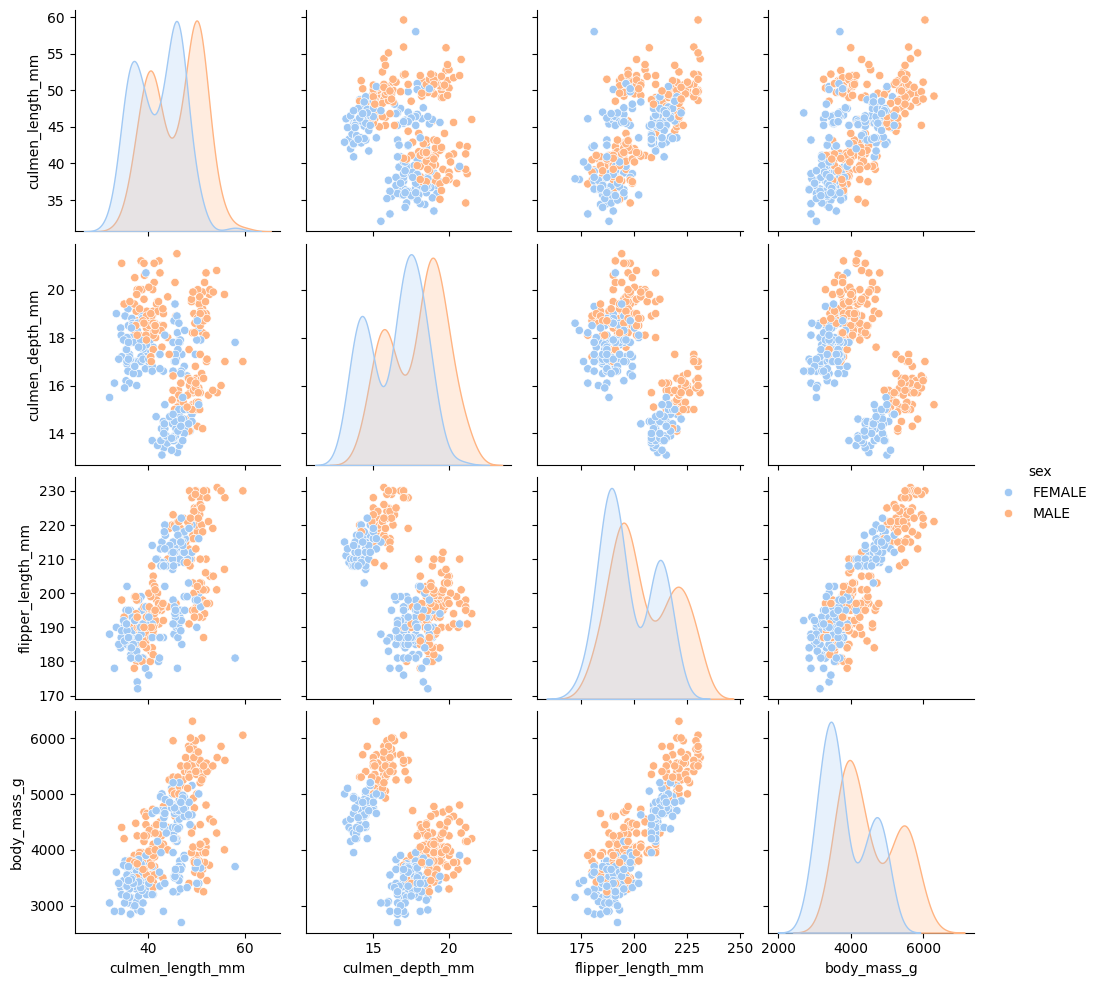

In [24]:
sns.pairplot(penguins_cleaned, hue="sex")
plt.show()

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(penguins_cleaned)
plt.title('企鹅数据热力图')
plt.show()

ValueError: could not convert string to float: 'Adelie'

<Figure size 1000x800 with 0 Axes>

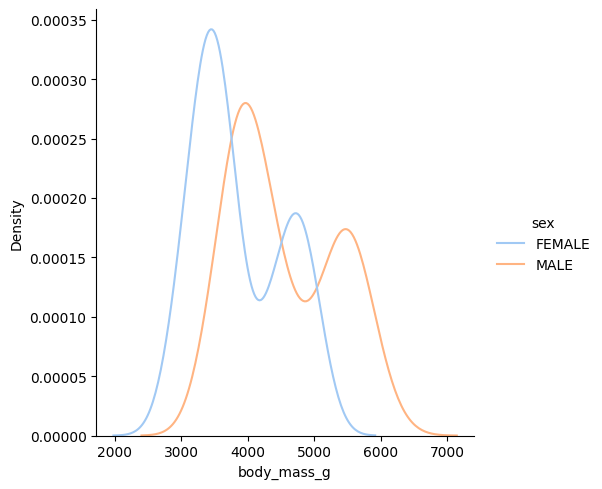

In [34]:
sns.displot(data=penguins_cleaned, x='body_mass_g',hue='sex',kind='kde')
plt.show()